## Dependencias

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

## Dataset

Dataset Content
Each entry in the dataset represents a stream of traffic to a web server, including the following columns:

bytes_in: Bytes received by the server.

bytes_out: Bytes sent from the server.

creation_time: Timestamp of when the record was created.

end_time: Timestamp of when the connection ended.

src_ip: Source IP address.

src_ip_country_code: Country code of the source IP.

protocol: Protocol used in the connection.

response.code: HTTP response code.

dst_port: Destination port on the server.

dst_ip: Destination IP address.

rule_names: Name of the rule that identified the traffic as suspicious.

observation_name: Observations associated with the traffic.

source.meta: Metadata related to the source.

source.name: Name of the traffic source.

time: Timestamp of the detected event.

detection_types: Type of detection applied.

https://www.kaggle.com/datasets/jancsg/cybersecurity-suspicious-web-threat-interactions

In [93]:
DATA_PATH = Path("CloudWatch_Traffic_Web_Attack.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


In [94]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones del dataset: (282, 16)

Columnas:
['bytes_in', 'bytes_out', 'creation_time', 'end_time', 'src_ip', 'src_ip_country_code', 'protocol', 'response.code', 'dst_port', 'dst_ip', 'rule_names', 'observation_name', 'source.meta', 'source.name', 'time', 'detection_types']


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

In [96]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bytes_in,282.0,NaN,NaN,NaN,1199390.191489,4149311.993487,40.0,5381.5,13182.0,30833.0,25207794.0
bytes_out,282.0,NaN,NaN,NaN,84554.29078,254927.899195,44.0,11142.0,13799.5,26279.5,1561220.0
creation_time,282,30,2024-04-26T09:00:00Z,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,282,30,2024-04-26T09:10:00Z,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip,282,28,165.225.209.4,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip_country_code,282,7,US,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
protocol,282,1,HTTPS,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response.code,282.0,NaN,NaN,NaN,200.0,0.0,200.0,200.0,200.0,200.0,200.0
dst_port,282.0,NaN,NaN,NaN,443.0,0.0,443.0,443.0,443.0,443.0,443.0
dst_ip,282,1,10.138.69.97,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Análisis exploratorio

In [97]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]

print("Columnas con valores nulos:")
display(nulls.to_frame("null_count"))

Columnas con valores nulos:


,null_count


In [98]:
duplicates = df.duplicated().sum()
print(f"Registros duplicados: {duplicates}")

Registros duplicados: 0


In [99]:
date_cols = ["creation_time", "end_time", "time"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].head()

,creation_time,end_time,time
0,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,2024-04-25 23:00:00+00:00
1,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,2024-04-25 23:00:00+00:00
2,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,2024-04-25 23:00:00+00:00
3,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,2024-04-25 23:00:00+00:00
4,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,2024-04-25 23:00:00+00:00


In [100]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Columnas numéricas:", numeric_cols)

df[numeric_cols].describe().T

Columnas numéricas: ['bytes_in', 'bytes_out', 'response.code', 'dst_port']


,count,mean,std,min,25%,50%,75%,max
bytes_in,282.0,1.199390e+06,4.149312e+06,40.0,5381.5,13182.0,30833.0,25207794.0
bytes_out,282.0,8.455429e+04,2.549279e+05,44.0,11142.0,13799.5,26279.5,1561220.0
response.code,282.0,2.000000e+02,0.000000e+00,200.0,200.0,200.0,200.0,200.0
dst_port,282.0,4.430000e+02,0.000000e+00,443.0,443.0,443.0,443.0,443.0


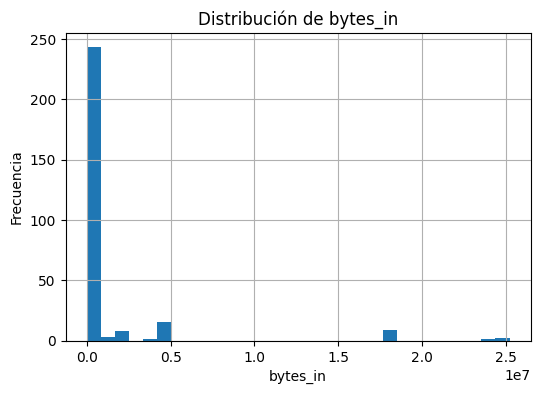

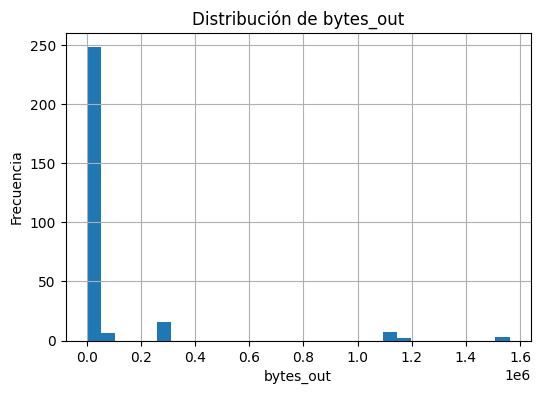

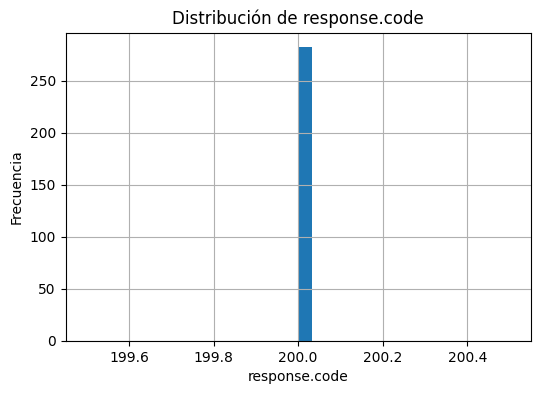

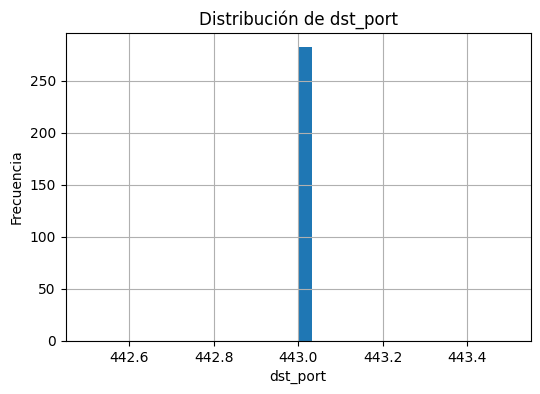

In [101]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df[col].dropna().hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

In [102]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Columnas categóricas:", categorical_cols)

Columnas categóricas: ['src_ip', 'src_ip_country_code', 'protocol', 'dst_ip', 'rule_names', 'observation_name', 'source.meta', 'source.name', 'detection_types']


In [103]:
cat_cols_to_review = [
    "protocol",
    "src_ip_country_code",
    "response.code",
    "rule_names",
    "observation_name",
    "source.meta",
    "source.name",
    "detection_types"
]

for col in cat_cols_to_review:
    if col in df.columns:
        print(f"\n--- Top valores de {col} ---")
        display(df[col].value_counts(dropna=False).head(15).to_frame("count"))


--- Top valores de protocol ---


,count
protocol,
HTTPS,282



--- Top valores de src_ip_country_code ---


,count
src_ip_country_code,
US,113
CA,72
DE,28
AT,21
NL,18
AE,16
IL,14



--- Top valores de response.code ---


...

,count
source.meta,
AWS_VPC_Flow,282



--- Top valores de source.name ---


,count
source.name,
prod_webserver,282



--- Top valores de detection_types ---


,count
detection_types,
waf_rule,282


In [104]:
if "creation_time" in df.columns and "end_time" in df.columns:
    df["duration_seconds"] = (df["end_time"] - df["creation_time"]).dt.total_seconds()
    print(df["duration_seconds"].describe())

count    282.0
mean     600.0
std        0.0
min      600.0
25%      600.0
50%      600.0
75%      600.0
max      600.0
Name: duration_seconds, dtype: float64


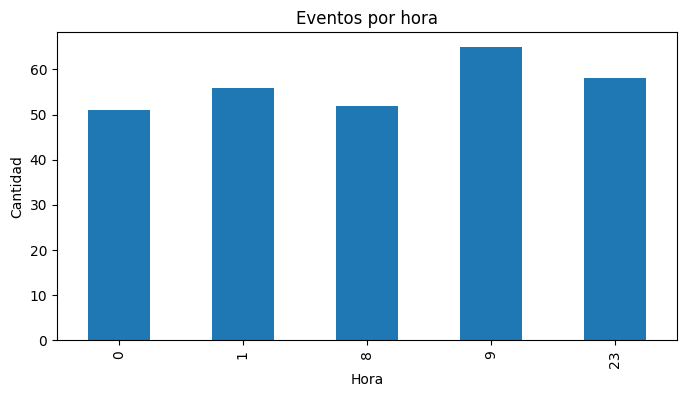

In [105]:
if "creation_time" in df.columns:
    df["event_hour"] = df["creation_time"].dt.hour
    df["event_dayofweek"] = df["creation_time"].dt.day_name()

    plt.figure(figsize=(8,4))
    df["event_hour"].value_counts().sort_index().plot(kind="bar")
    plt.title("Eventos por hora")
    plt.xlabel("Hora")
    plt.ylabel("Cantidad")
    plt.show()

In [106]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return pd.Series({
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outliers
    })

for col in numeric_cols:
    print(f"\nOutliers estimados para {col}")
    display(iqr_outlier_summary(df[col].dropna()).to_frame("value"))


Outliers estimados para bytes_in


,value
q1,5381.50
q3,30833.00
iqr,25451.50
lower_bound,-32795.75
upper_bound,69010.25
outlier_count,40.00



Outliers estimados para bytes_out


,value
q1,11142.00
q3,26279.50
iqr,15137.50
lower_bound,-11564.25
upper_bound,48985.75
outlier_count,37.00



Outliers estimados para response.code


,value
q1,200.0
q3,200.0
iqr,0.0
lower_bound,200.0
upper_bound,200.0
outlier_count,0.0



Outliers estimados para dst_port


,value
q1,443.0
q3,443.0
iqr,0.0
lower_bound,443.0
upper_bound,443.0
outlier_count,0.0


## Limpieza

In [107]:
df = df.drop_duplicates().copy()
print("Nuevo tamaño después de quitar duplicados:", df.shape)

Nuevo tamaño después de quitar duplicados: (282, 19)


In [108]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(".", "_", regex=False)
              .str.replace(" ", "_", regex=False)
)

print(df.columns.tolist())

['bytes_in', 'bytes_out', 'creation_time', 'end_time', 'src_ip', 'src_ip_country_code', 'protocol', 'response_code', 'dst_port', 'dst_ip', 'rule_names', 'observation_name', 'source_meta', 'source_name', 'time', 'detection_types', 'duration_seconds', 'event_hour', 'event_dayofweek']


In [109]:
df.isnull().sum().sort_values(ascending=False).head(20)

bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response_code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source_meta            0
source_name            0
time                   0
detection_types        0
duration_seconds       0
event_hour             0
event_dayofweek        0
dtype: int64

## Características

In [110]:

if {"creation_time", "end_time"}.issubset(df.columns):
    df["duration_seconds"] = (df["end_time"] - df["creation_time"]).dt.total_seconds()

if "creation_time" in df.columns:
    df["event_hour"] = df["creation_time"].dt.hour
    df["event_dayofweek"] = df["creation_time"].dt.dayofweek
    df["event_month"] = df["creation_time"].dt.month

In [111]:
if {"bytes_in", "bytes_out"}.issubset(df.columns):
    df["total_bytes"] = df["bytes_in"].fillna(0) + df["bytes_out"].fillna(0)
    df["bytes_ratio_out_in"] = df["bytes_out"] / (df["bytes_in"] + 1)


In [112]:
common_ports = {80, 443, 21, 22, 25, 53, 110, 143, 3306, 8080}

if "dst_port" in df.columns:
    df["is_common_port"] = df["dst_port"].apply(lambda x: 1 if x in common_ports else 0)



In [113]:
import ipaddress

def is_private_ip(ip):
    try:
        return int(ipaddress.ip_address(ip).is_private)
    except:
        return np.nan

for col in ["src_ip", "dst_ip"]:
    if col in df.columns:
        df[f"{col}_is_private"] = df[col].apply(is_private_ip)


In [114]:
for col in ["rule_names", "observation_name", "source_meta", "source_name", "detection_types"]:
    if col in df.columns:
        df[f"{col}_len"] = df[col].astype(str).str.len()

In [115]:
df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response_code,dst_port,dst_ip,...,total_bytes,bytes_ratio_out_in,is_common_port,src_ip_is_private,dst_ip_is_private,rule_names_len,observation_name_len,source_meta_len,source_name_len,detection_types_len
0,5602,12990,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,...,18592,2.318401,1,0,1,22,36,12,14,8
1,30912,18186,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.33.6,US,HTTPS,200,443,10.138.69.97,...,49098,0.588296,1,0,1,22,36,12,14,8
2,28506,13468,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,...,41974,0.472445,1,0,1,22,36,12,14,8
3,30546,14278,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,136.226.64.114,US,HTTPS,200,443,10.138.69.97,...,44824,0.467411,1,0,1,22,36,12,14,8
4,6526,13892,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,...,20418,2.128390,1,0,1,22,36,12,14,8


## Características

In [116]:
if "detection_types" in df.columns:
    df["target"] = df["detection_types"].notna().astype(int)
    print(df["target"].value_counts())

target
1    282
Name: count, dtype: int64


In [117]:
target_col = "target"

df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response_code,dst_port,dst_ip,...,bytes_ratio_out_in,is_common_port,src_ip_is_private,dst_ip_is_private,rule_names_len,observation_name_len,source_meta_len,source_name_len,detection_types_len,target
0,5602,12990,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,...,2.318401,1,0,1,22,36,12,14,8,1
1,30912,18186,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.33.6,US,HTTPS,200,443,10.138.69.97,...,0.588296,1,0,1,22,36,12,14,8,1
2,28506,13468,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,...,0.472445,1,0,1,22,36,12,14,8,1
3,30546,14278,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,136.226.64.114,US,HTTPS,200,443,10.138.69.97,...,0.467411,1,0,1,22,36,12,14,8,1
4,6526,13892,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,...,2.128390,1,0,1,22,36,12,14,8,1


In [118]:
target_col = "target"

drop_cols = [
    "src_ip",
    "dst_ip",
    "creation_time",
    "end_time",
    "time"
]

leakage_cols = [
    "rule_names",
    "observation_name",
    "detection_types"
]

existing_drop_cols = [c for c in drop_cols if c in df.columns]
existing_leakage_cols = [c for c in leakage_cols if c in df.columns]

base_feature_cols = [c for c in df.columns if c not in existing_drop_cols + [target_col]]
safe_feature_cols = [c for c in df.columns if c not in existing_drop_cols + existing_leakage_cols + [target_col]]

print("Features base:", base_feature_cols)
print("Features seguras (sin posible leakage):", safe_feature_cols)

Features base: ['bytes_in', 'bytes_out', 'src_ip_country_code', 'protocol', 'response_code', 'dst_port', 'rule_names', 'observation_name', 'source_meta', 'source_name', 'detection_types', 'duration_seconds', 'event_hour', 'event_dayofweek', 'event_month', 'total_bytes', 'bytes_ratio_out_in', 'is_common_port', 'src_ip_is_private', 'dst_ip_is_private', 'rule_names_len', 'observation_name_len', 'source_meta_len', 'source_name_len', 'detection_types_len']
Features seguras (sin posible leakage): ['bytes_in', 'bytes_out', 'src_ip_country_code', 'protocol', 'response_code', 'dst_port', 'source_meta', 'source_name', 'duration_seconds', 'event_hour', 'event_dayofweek', 'event_month', 'total_bytes', 'bytes_ratio_out_in', 'is_common_port', 'src_ip_is_private', 'dst_ip_is_private', 'rule_names_len', 'observation_name_len', 'source_meta_len', 'source_name_len', 'detection_types_len']


In [119]:
X = df[safe_feature_cols].copy()
y = df[target_col].copy()

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", num_features)
print("Categóricas:", cat_features)

Numéricas: ['bytes_in', 'bytes_out', 'response_code', 'dst_port', 'duration_seconds', 'event_hour', 'event_dayofweek', 'event_month', 'total_bytes', 'bytes_ratio_out_in', 'is_common_port', 'src_ip_is_private', 'dst_ip_is_private', 'rule_names_len', 'observation_name_len', 'source_meta_len', 'source_name_len', 'detection_types_len']
Categóricas: ['src_ip_country_code', 'protocol', 'source_meta', 'source_name']


In [120]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        57

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57

